**Ανάλυση Δεδομένων**

**Βαρελάς Κωνσταντίνος**

**Εργασία: Credit Risk Dataset**

**Dataset** : https://www.kaggle.com/datasets/laotse/credit-risk-dataset/data

In [17]:
import pandas as pd
import numpy as np

print(f"Pandas version: {pd.__version__}")

import matplotlib.pyplot as plt

credit_risk_dataset = pd.read_csv("credit_risk_dataset.csv",sep=",")
print(f"Dataset: {credit_risk_dataset.shape[0]} γραμμές, {credit_risk_dataset.shape[1]} στήλες")

Pandas version: 2.3.3
Dataset: 32581 γραμμές, 12 στήλες


In [18]:
file = "credit_risk_dataset.csv"
credit_risk_dataset = pd.read_csv(file,sep=',')

In [19]:


file = "credit_risk_dataset.csv"
credit_risk_dataset = pd.read_csv(file,sep=",")
print(credit_risk_dataset)

       person_age  person_income person_home_ownership  person_emp_length  \
0              22          59000                  RENT              123.0   
1              21           9600                   OWN                5.0   
2              25           9600              MORTGAGE                1.0   
3              23          65500                  RENT                4.0   
4              24          54400                  RENT                8.0   
...           ...            ...                   ...                ...   
32576          57          53000              MORTGAGE                1.0   
32577          54         120000              MORTGAGE                4.0   
32578          65          76000                  RENT                3.0   
32579          56         150000              MORTGAGE                5.0   
32580          66          42000                  RENT                2.0   

           loan_intent loan_grade  loan_amnt  loan_int_rate  loan_status  \

In [20]:
print(credit_risk_dataset.shape)

(32581, 12)


To dataset έχει 32581
**αντικείμενα** και 12 **μεταβλητές**

In [21]:
print(credit_risk_dataset.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32581 entries, 0 to 32580
Data columns (total 12 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   person_age                  32581 non-null  int64  
 1   person_income               32581 non-null  int64  
 2   person_home_ownership       32581 non-null  object 
 3   person_emp_length           31686 non-null  float64
 4   loan_intent                 32581 non-null  object 
 5   loan_grade                  32581 non-null  object 
 6   loan_amnt                   32581 non-null  int64  
 7   loan_int_rate               29465 non-null  float64
 8   loan_status                 32581 non-null  int64  
 9   loan_percent_income         32581 non-null  float64
 10  cb_person_default_on_file   32581 non-null  object 
 11  cb_person_cred_hist_length  32581 non-null  int64  
dtypes: float64(3), int64(5), object(4)
memory usage: 3.0+ MB
None


In [22]:
print(credit_risk_dataset["person_home_ownership"].unique())

print(credit_risk_dataset["loan_intent"].unique())

print(credit_risk_dataset["loan_grade"].unique())

print(credit_risk_dataset["cb_person_default_on_file"].unique())



['RENT' 'OWN' 'MORTGAGE' 'OTHER']
['PERSONAL' 'EDUCATION' 'MEDICAL' 'VENTURE' 'HOMEIMPROVEMENT'
 'DEBTCONSOLIDATION']
['D' 'B' 'C' 'A' 'E' 'F' 'G']
['Y' 'N']


**Στοιχεία πελάτη**:'person_age'= ηλικία πελάτη , 'person_income'= είσοδημα του πελάτη, 'person_home_ownership'= το καθεστώς ιδιοκτησίας σπιτιού, 'person_emp_length'= χρόνια εργασίας

**Στοιχεία Δανείου**:'loan_intent'= σκοπός αίτησης δανείου, 'loan_amnt'= ποσό δανείου, 'loan_int_rate'= επιτόκιο δανείου, 'loan_status'= κατάσταση δανείου, 'loan_percent_income'= ποσοστό ετησίου εισοδήματος που αντιπροσωπευεί το δάνειο, 'loan_grade'= βαθμός δανείου 

**Άλλα στοιχεία**:'cb_person_default_on_file'= ιστορικό αθέτησης πληρωμών, 'cb_person_cred_hist_length'= διάρκεια πιστωτικού ιστορικού



In [23]:
print(credit_risk_dataset.isna().sum())
missing_counts = credit_risk_dataset.isna().sum()
print("Στήλες με ελλείπουσες τιμές:\n", missing_counts[missing_counts > 0])

person_age                       0
person_income                    0
person_home_ownership            0
person_emp_length              895
loan_intent                      0
loan_grade                       0
loan_amnt                        0
loan_int_rate                 3116
loan_status                      0
loan_percent_income              0
cb_person_default_on_file        0
cb_person_cred_hist_length       0
dtype: int64
Στήλες με ελλείπουσες τιμές:
 person_emp_length     895
loan_int_rate        3116
dtype: int64


**Στήλες με ελλείπουσες τιμές**: 

'person_emp_length': 895

'loan_int_rate': 3116

In [24]:
print("μοναδικές τιμές της στήλης:",credit_risk_dataset["loan_status"].unique())

μοναδικές τιμές της στήλης: [1 0]


In [25]:
print(credit_risk_dataset["loan_status"].value_counts())

loan_status
0    25473
1     7108
Name: count, dtype: int64


Υποθέτω για τα δεδομένα μου ότι :

**Μεταβλητή στόχος** για το dataset είναι η **"loan_status"**

**Μεταβλητές που επηραζούν τη μεταβλητή στόχος** για το dataset είναι η **"loan_percent_income"**, **"loan_int_rate"**, **"loan_grade"**, **loan_amnt"**, **"cb_person_default_on_file"**, **"cb_person_cred_hist_length"**, **"person_income"**

**Αδιάφορες μεταβλητές** για το dataset είναι **"person_age"**, **"loan_intent"**, **"person_emp_length"**, **"person_home_ownership"**

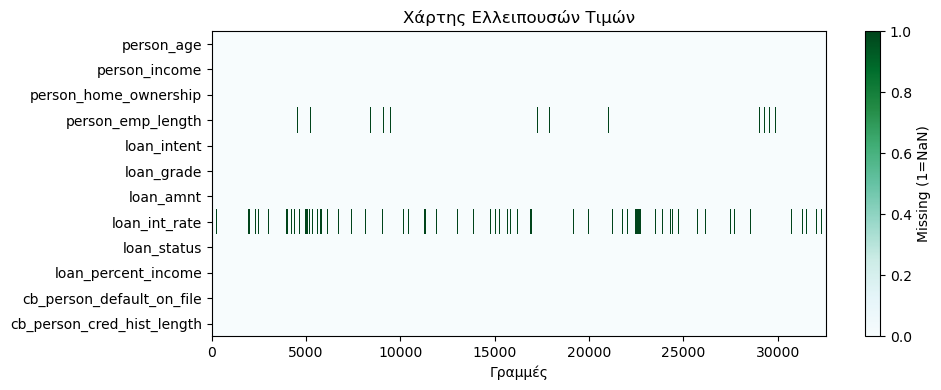

In [26]:
plt.figure(figsize=(10, 4))
plt.imshow(credit_risk_dataset.isna().T, aspect='auto', cmap='BuGn', interpolation='none')
plt.colorbar(label='Missing (1=NaN)')
plt.yticks(range(len(titanic.columns)), titanic.columns)
plt.xlabel('Γραμμές')
plt.title('Χάρτης Ελλειπουσών Τιμών')
plt.tight_layout()
plt.show()

In [27]:
credit_risk_dataset_clean = credit_risk_dataset.copy()

credit_risk_dataset_clean = credit_risk_dataset_clean.dropna(subset=["loan_int_rate"])
print(credit_risk_dataset_clean.dropna(subset=["loan_int_rate"]))

print("Πριν:", credit_risk_dataset.shape)
print("Μετά:", credit_risk_dataset_clean.shape)

       person_age  person_income person_home_ownership  person_emp_length  \
0              22          59000                  RENT              123.0   
1              21           9600                   OWN                5.0   
2              25           9600              MORTGAGE                1.0   
3              23          65500                  RENT                4.0   
4              24          54400                  RENT                8.0   
...           ...            ...                   ...                ...   
32576          57          53000              MORTGAGE                1.0   
32577          54         120000              MORTGAGE                4.0   
32578          65          76000                  RENT                3.0   
32579          56         150000              MORTGAGE                5.0   
32580          66          42000                  RENT                2.0   

           loan_intent loan_grade  loan_amnt  loan_int_rate  loan_status  \

In [28]:
mean_person_emp_length = credit_risk_dataset_clean['person_emp_length'].mean()
print("Χρόνια εργασίας:", mean_person_emp_length)

credit_risk_dataset_clean['person_emp_length'] = credit_risk_dataset_clean['person_emp_length'].fillna(mean_person_emp_length)

credit_risk_dataset_clean['person_emp_length'].isna().sum()

Χρόνια εργασίας: 4.788672393323556


np.int64(0)